# Fraud detection with XGBoost

Inspired by
- [XGBoost in Python from Start to Finish](https://www.youtube.com/watch?v=GrJP9FLV3FE) 


### For macOS users

You may get an error about **OpenMP** / **libomp.dylib** when importing XGBoost, it is recommended to install Apple’s OpenMP runtime 

`brew install libomp`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import random

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_SEED = 42
IMAGE_DIR = "../../results/images/XGBoost"

random.seed(RANDOM_SEED)

### Load train / validation / test



In [2]:
DATA_ROOT = Path("../../data/processed/supervised")

train_df = pd.read_csv(DATA_ROOT / "train_data.csv")
val_df = pd.read_csv(DATA_ROOT / "val_data.csv")
test_df = pd.read_csv(DATA_ROOT / "test_data.csv")

feature_cols = [c for c in train_df.columns if c != "fraud"]

X_train = train_df[feature_cols]
y_train = train_df["fraud"]

X_val = val_df[feature_cols]
y_val = val_df["fraud"]

X_test = test_df[feature_cols]
y_test = test_df["fraud"]

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
print("Train fraud rate:", y_train.mean().round(6))
print("Val fraud rate:  ", y_val.mean().round(6))
print("Test fraud rate: ", y_test.mean().round(6))
print("Features:", len(feature_cols))

Train: (417847, 31) | Val: (87702, 31) | Test: (89093, 31)
Train fraud rate: 0.012636
Val fraud rate:   0.010946
Test fraud rate:  0.010775
Features: 30


### Train XGBoost for classification

### Hyperparameter Search

In [3]:
seen = set()
results = []

while len(results) < 10:
    params = {
        "learning_rate": random.choice([0.01, 0.05, 0.1]),
        "max_depth": random.choice([3, 4, 5, 6]),
        "subsample": random.choice([0.8, 0.9, 1.0])
    }

    key = tuple(params.items())
    if key in seen:
        continue
    seen.add(key)

    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = neg / max(pos, 1)

    model = XGBClassifier(
        n_estimators=500,
        **params,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        tree_method="hist",
        early_stopping_rounds=50,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    y_pred = model.predict(X_val)
    probs_val = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    perc = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    roc_auc = roc_auc_score(y_val, probs_val)
    pr_auc = average_precision_score(y_val, probs_val)

    results.append({
        "params": params,
        "accuracy": acc,
        "precision": perc,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })

In [4]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="pr_auc", ascending=False)

results_df

,params,accuracy,precision,recall,f1_score,roc_auc,pr_auc
8,"{'learning_rate': 0.05, 'max_depth': 5, 'subsa...",0.994687,0.685157,0.952083,0.796861,0.999223,0.952849
1,"{'learning_rate': 0.1, 'max_depth': 5, 'subsam...",0.995063,0.704422,0.945833,0.807470,0.999215,0.952074
0,"{'learning_rate': 0.1, 'max_depth': 3, 'subsam...",0.993079,0.616656,0.971875,0.754549,0.999180,0.951282
4,"{'learning_rate': 0.05, 'max_depth': 3, 'subsa...",0.991676,0.570293,0.971875,0.718798,0.999145,0.949157
6,"{'learning_rate': 0.1, 'max_depth': 3, 'subsam...",0.991243,0.557692,0.966667,0.707317,0.999014,0.945142
5,"{'learning_rate': 0.01, 'max_depth': 4, 'subsa...",0.984721,0.416813,0.991667,0.586930,0.998907,0.933838
2,"{'learning_rate': 0.01, 'max_depth': 4, 'subsa...",0.984801,0.418022,0.990625,0.587944,0.998848,0.930707
3,"{'learning_rate': 0.01, 'max_depth': 3, 'subsa...",0.984767,0.416740,0.980208,0.584835,0.998701,0.924304
9,"{'learning_rate': 0.01, 'max_depth': 6, 'subsa...",0.986123,0.440260,0.986458,0.608807,0.998869,0.920293
7,"{'learning_rate': 0.01, 'max_depth': 6, 'subsa...",0.986317,0.443662,0.984375,0.611650,0.998841,0.917919


In [5]:
best_results = results_df.iloc[0]
best_params = best_results['params']

print("Best hyperparameters:", best_params)
print("Validation Accuracy:", best_results['accuracy'])
print("Validation Precision:", best_results['precision'])
print("Validation Recall:", best_results['recall'])
print("Validation F1 Score:", best_results['f1_score'])
print("Validation ROC AUC:", best_results['roc_auc'])
print("Validation PR AUC:", best_results['pr_auc'])

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8}
Validation Accuracy: 0.9946865521880915
Validation Precision: 0.6851574212893553
Validation Recall: 0.9520833333333333
Validation F1 Score: 0.7968613775065388
Validation ROC AUC: 0.999223355371869
Validation PR AUC: 0.9528487472932853


### PR curve of validation set

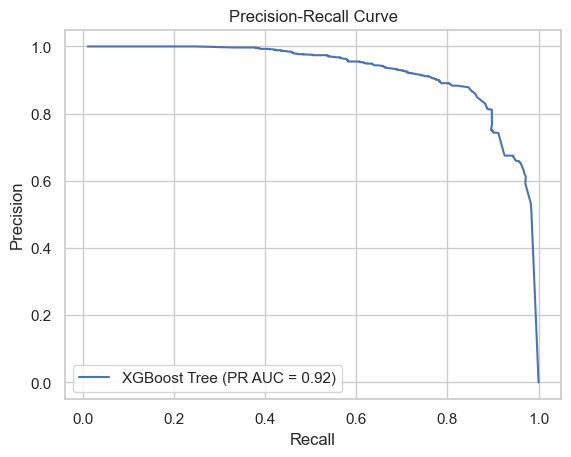

In [6]:
precision, recall, _ = precision_recall_curve(y_val, probs_val)

plt.plot(precision, recall, label=f'XGBoost Tree (PR AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/pr_curve_validation.svg')
plt.show()

### Train on the best model

In [7]:
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

model = XGBClassifier(
    n_estimators=2000,
    **best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    tree_method="hist",
    early_stopping_rounds=50,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=150,
)

print("Best iteration (0-based):", model.best_iteration)
print("Best validation score (aucpr):", model.best_score)

[0]	validation_0-aucpr:0.86567
[150]	validation_0-aucpr:0.94465
[300]	validation_0-aucpr:0.95061
[450]	validation_0-aucpr:0.95251
[595]	validation_0-aucpr:0.95279
Best iteration (0-based): 545
Best validation score (aucpr): 0.9529612385378656


In [8]:
probs_val = model.predict_proba(X_val)[:, 1]
precision, recall, threshold = precision_recall_curve(y_val, probs_val)

f1_scores = 2 * (precision * recall) / (precision + recall)

beta = 2    # Makes F2 score, puts more emphasis on recall
fbeta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-8)
best_index = fbeta_scores.argmax()

optimal_threshold = threshold[best_index]

probs_test = model.predict_proba(X_test)[:, 1]
y_pred = (probs_test >= optimal_threshold).astype(int)

print("Test Accuracy: ", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Test Recall:   ", recall_score(y_test, y_pred, zero_division=0))
print("Test F1:       ", f1_score(y_test, y_pred, zero_division=0))
print("Test ROC AUC:  ", roc_auc_score(y_test, probs_test))
print("Test PR AUC:   ", average_precision_score(y_test, probs_test))

Test Accuracy:  0.9965429382779792
Test Precision: 0.8012939001848429
Test Recall:    0.903125
Test F1:        0.8491674828599413
Test ROC AUC:   0.9991209367754795
Test PR AUC:    0.9469698254065203


### Save the model and threshold

In [9]:
Path("../../results/models").mkdir(parents=True, exist_ok=True)
joblib.dump({"model": model, "threshold": optimal_threshold}, '../../results/models/xgboost.pkl')

['../../results/models/xgboost.pkl']

### XGBoost Tree Visualisation



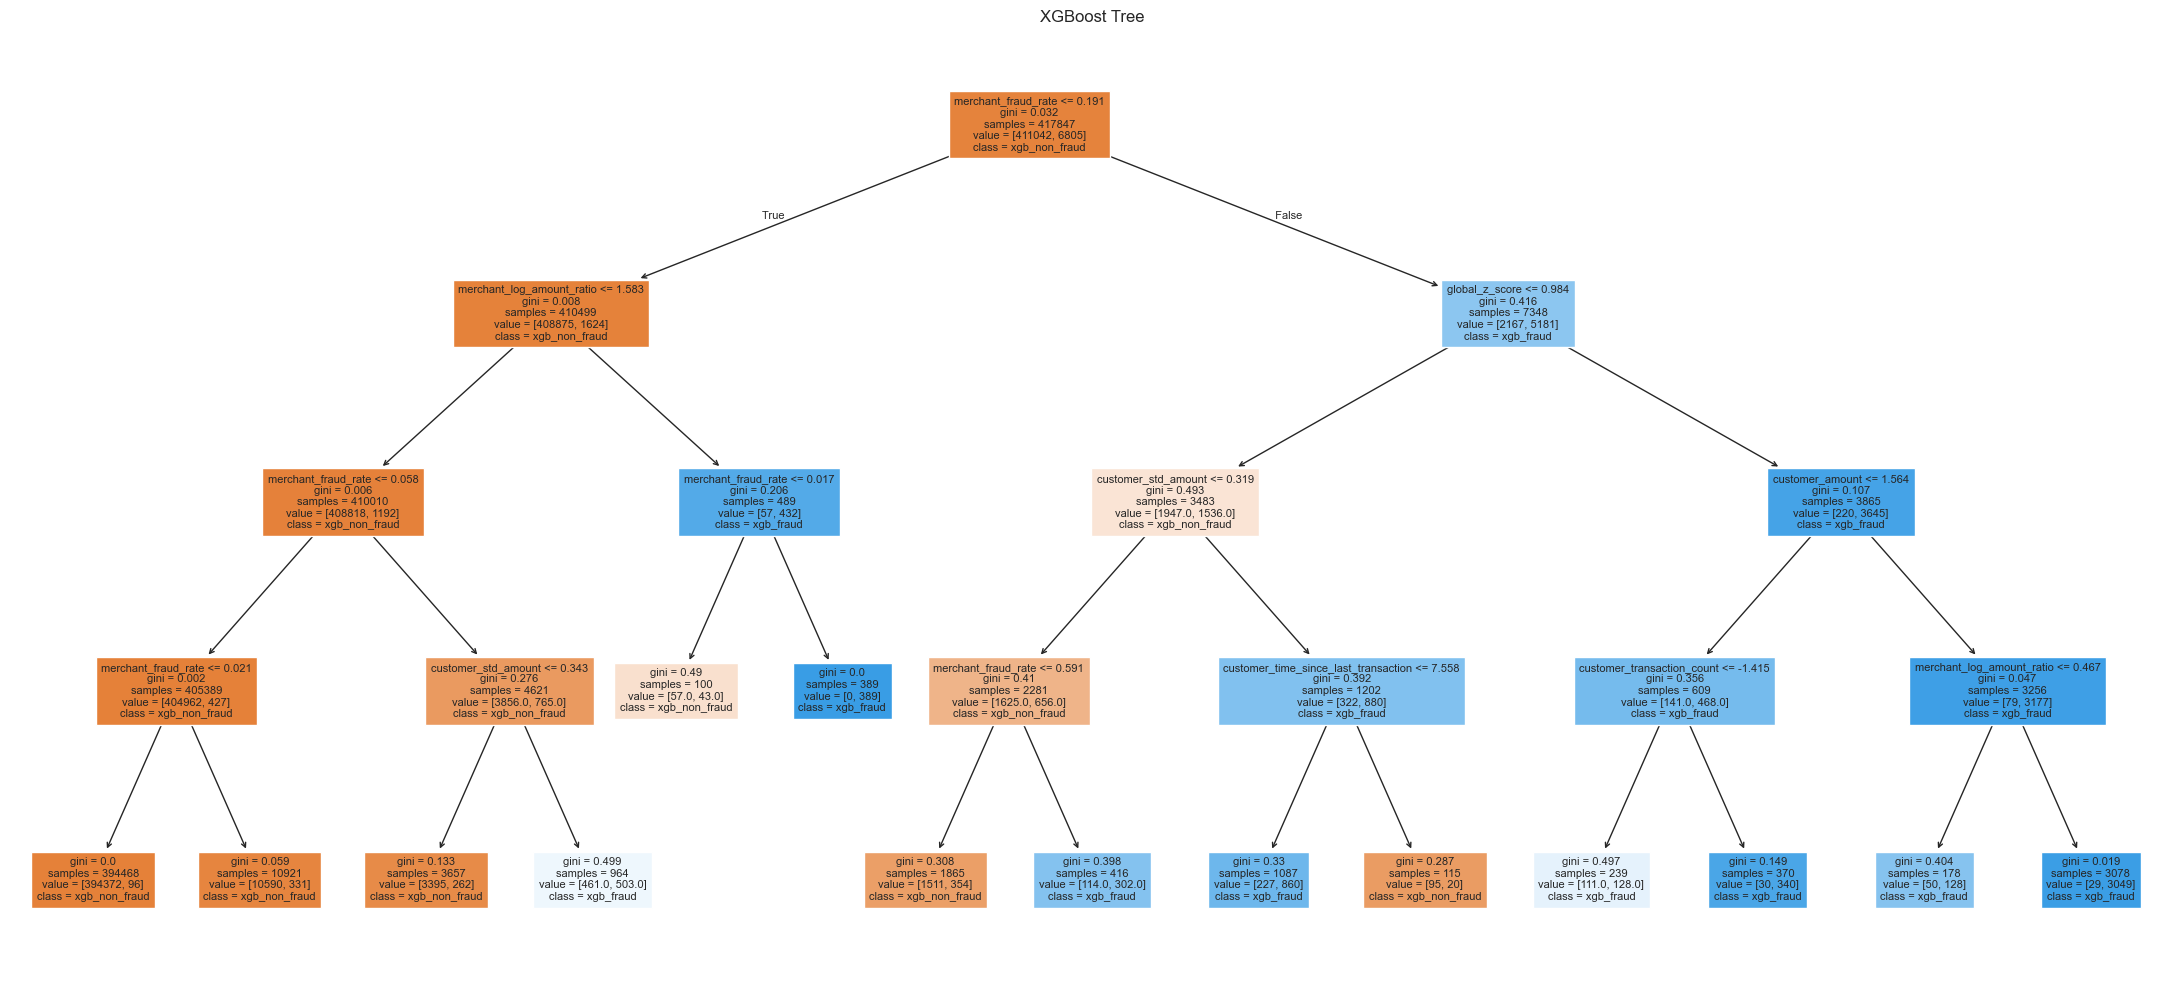

In [10]:
xgb_prob_train = model.predict_proba(X_train)[:, 1]
xgb_label_train = (xgb_prob_train >= optimal_threshold).astype(int)

decision_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, random_state=RANDOM_SEED)
decision_tree.fit(X_train, xgb_label_train)

plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=feature_cols,
    class_names=["xgb_non_fraud", "xgb_fraud"],
    filled=True,
    max_depth=10,
    fontsize=8,
)
plt.title("XGBoost Tree")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/xgboost_decision_tree.svg')
plt.show()


### PR AUC curve for test set


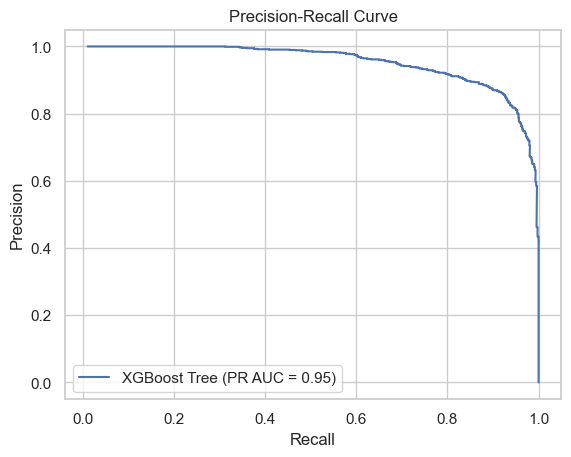

In [11]:
from pathlib import Path

plt.plot(precision, recall, label=f'XGBoost Tree (PR AUC = {(average_precision_score(y_test, probs_test)):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
Path(IMAGE_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f'{IMAGE_DIR}/pr_curve_test.svg')
plt.show()

### Confusion matrix based on threshold

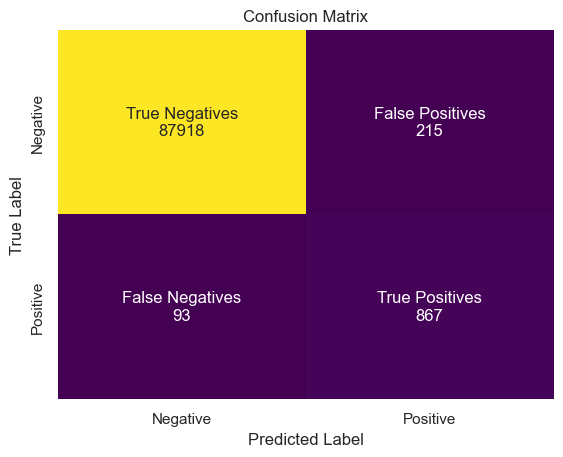

In [12]:
cf_matrix = confusion_matrix(y_test, y_pred)

group_names = ["True Negatives", "False Positives", "False Negatives", "True Positives"]

group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.array(labels).reshape(2,2)

matrix = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap="viridis", cbar=False)
matrix.set_xlabel("Predicted Label")
matrix.set_ylabel("True Label")
matrix.set_xticklabels(["Negative", "Positive"])
matrix.set_yticklabels(["Negative", "Positive"])
plt.title('Confusion Matrix')
plt.savefig(f'{IMAGE_DIR}/confusion_matrix.svg')
plt.show()

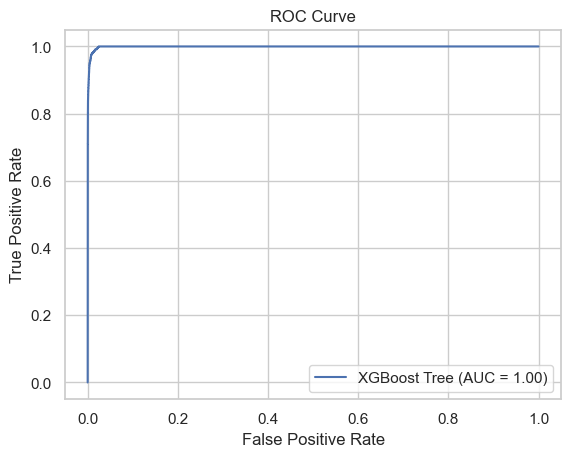

In [13]:
fpr, tpr, _ = roc_curve(y_test, probs_test)

plt.plot(fpr, tpr, label=f'XGBoost Tree (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/roc_curve_test.svg')
plt.show()

### Feature importance

,feature,importance
0,merchant_fraud_rate,0.686220
1,global_log_median_amount_ratio,0.032637
2,customer_amount,0.032534
3,global_z_score,0.030147
4,merchant_transaction_count,0.026081
5,customer_std_amount,0.022169
6,merchant_log_amount_ratio,0.014334
7,merchant_std_amount,0.013877
8,customer_category_count,0.011945
9,customer_time_since_last_transaction,0.011119


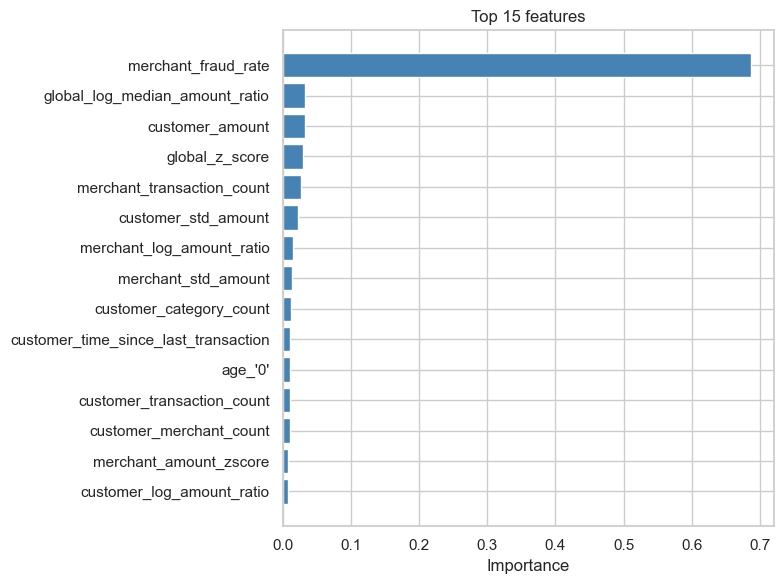

In [14]:
fi = (
    pd.DataFrame({"feature": feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(fi.head(20))

top_k = 15
sub = fi.head(top_k).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sub["feature"], sub["importance"], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} features")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/feature_importance.svg')
plt.show()

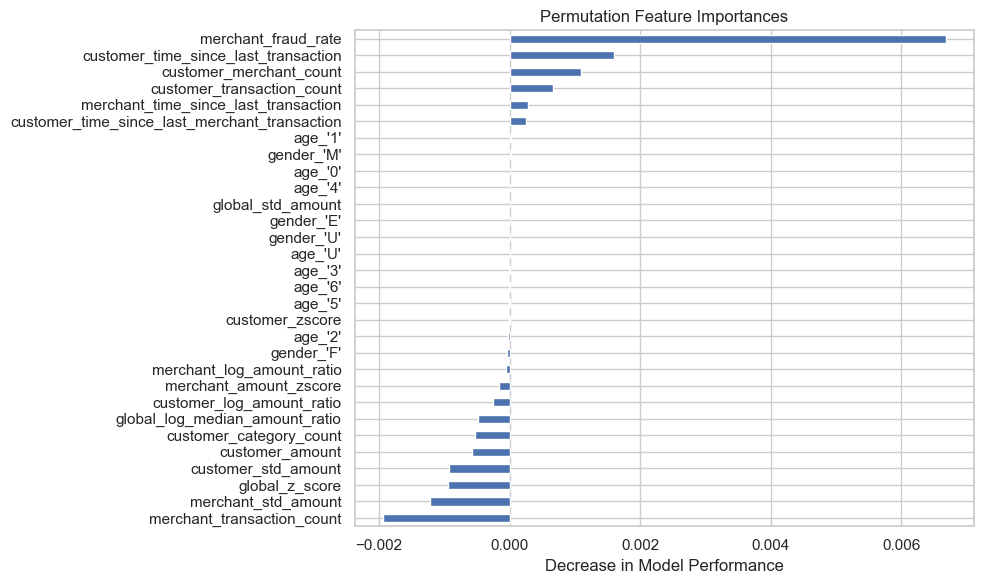

In [15]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_imp.sort_values().plot(kind='barh')
plt.title("Permutation Feature Importances")
plt.xlabel("Decrease in Model Performance")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/permutation_importance.svg')
plt.show()